In [2]:
import os
import numpy as np
import torch
from PIL import Image
from transformers import AutoImageProcessor, ViTModel

device = "cuda" if torch.cuda.is_available() else "cpu"

# Supervised ViT baseline (ImageNet)
repo_id = "google/vit-base-patch16-224"

processor = AutoImageProcessor.from_pretrained(repo_id)
model = ViTModel.from_pretrained(repo_id).to(device)
model.eval()

print("device:", device)
print("hidden_size:", model.config.hidden_size)
print("num_hidden_layers:", model.config.num_hidden_layers)
print("image_size(config):", getattr(model.config, "image_size", None))
print("patch_size:", model.config.patch_size)

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.weight | MISSING    | 
pooler.dense.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


device: cuda
hidden_size: 768
num_hidden_layers: 12
image_size(config): 224
patch_size: 16


In [3]:
# load images (same as your DinoV3 notebook)
import os
from scipy.io import loadmat

datapath = '../data'
filename = 'miguel_passive8x4.mat'
filepath = os.path.join(datapath, filename)

img_mat = loadmat(filepath)
img = img_mat['img'].astype(np.float32)

# your original notebook: images_gray is (n_images, H, W)
images_gray = np.transpose(img, (2, 0, 1))
print('images_gray:', images_gray.shape, images_gray.min(), images_gray.max())
print("num images:", len(images_gray))

images_gray: (32, 150, 600) 0.0 255.0
num images: 32


In [4]:
images_rgb = []
for i in range(len(images_gray)):
    im = images_gray[i]

    im = Image.fromarray(im.astype(np.uint8))
    if im.size != (256, 64):
        im = im.resize((256, 64), resample=Image.BICUBIC)
    im = im.convert("RGB")

    images_rgb.append(im)

print("prepared images_rgb:", len(images_rgb))

prepared images_rgb: 32


In [5]:
# forward pass + hidden states
with torch.no_grad():
    inputs = processor(
        images=images_rgb,
        return_tensors="pt",
        do_resize=False,
        do_center_crop=False
    )
    for k, v in inputs.items():
        print(k, v.shape, v.dtype)

    inputs = {k: v.to(device) for k, v in inputs.items()}

    outputs = model(
        **inputs,
        output_hidden_states=True,
        interpolate_pos_encoding=True
    )
    hidden_states = outputs.hidden_states

print("len(hidden_states) =", len(hidden_states), "(= embedding + num_layers)")
print("layer0 shape:", hidden_states[0].shape)
print("last layer shape:", hidden_states[-1].shape)

/home/carsen/anaconda3/envs/dinov3_env/lib/python3.10/site-packages/transformers/image_processing_utils.py:50: UserWarning: The following named arguments are not valid for `ViTImageProcessor.preprocess` and were ignored: 'do_center_crop'
  return self.preprocess(images, *args, **kwargs)


pixel_values torch.Size([32, 3, 64, 256]) torch.float32
len(hidden_states) = 13 (= embedding + num_layers)
layer0 shape: torch.Size([32, 65, 768])
last layer shape: torch.Size([32, 65, 768])


In [6]:
# check the range of hidden states for each layer
for li in range(len(hidden_states)):
    hs = hidden_states[li]
    print(f"Layer {li}: shape={hs.shape}, min={hs.min().item():.4f}, max={hs.max().item():.4f}")

Layer 0: shape=torch.Size([32, 65, 768]), min=-6.8021, max=6.2059
Layer 1: shape=torch.Size([32, 65, 768]), min=-9.4481, max=22.7514
Layer 2: shape=torch.Size([32, 65, 768]), min=-9.3287, max=24.9687
Layer 3: shape=torch.Size([32, 65, 768]), min=-13.2018, max=27.9229
Layer 4: shape=torch.Size([32, 65, 768]), min=-28.2688, max=39.6894
Layer 5: shape=torch.Size([32, 65, 768]), min=-261.2930, max=278.0878
Layer 6: shape=torch.Size([32, 65, 768]), min=-650.5417, max=939.1052
Layer 7: shape=torch.Size([32, 65, 768]), min=-990.5358, max=1451.6091
Layer 8: shape=torch.Size([32, 65, 768]), min=-1040.3320, max=1506.3254
Layer 9: shape=torch.Size([32, 65, 768]), min=-1067.7972, max=1533.9747
Layer 10: shape=torch.Size([32, 65, 768]), min=-1100.5372, max=1598.1071
Layer 11: shape=torch.Size([32, 65, 768]), min=-1072.9183, max=1580.2539
Layer 12: shape=torch.Size([32, 65, 768]), min=-1017.3509, max=1615.3876


In [7]:
# save hidden states array: (num_layers+1, B, seq_len, dim)
hidden_states_array = torch.stack(hidden_states, dim=0).cpu().numpy()
print("hidden_states_array shape:", hidden_states_array.shape)

os.makedirs("outputs", exist_ok=True)
np.save("outputs/sup_vit_hidden_states.npy", hidden_states_array)

# zscore across feature dimension (same style as your DinoV3 notebook)
mean_all = hidden_states_array.mean(axis=-1, keepdims=True)
std_all = hidden_states_array.std(axis=-1, keepdims=True) + 1e-8
hidden_states_array_zscore = (hidden_states_array - mean_all) / std_all
print("hidden_states_array_zscore:", hidden_states_array_zscore.shape)

hidden_states_array shape: (13, 32, 65, 768)
hidden_states_array_zscore: (13, 32, 65, 768)


In [8]:
# pool patch tokens (excluding CLS). For supervised ViT there are no register tokens.
patch_start = 1  # CLS is token 0
patch_tokens = hidden_states_array_zscore[:, :, patch_start:, :]  # (layers, B, num_patches, dim)
pooled_patch_tokens = patch_tokens.mean(axis=2)  # (layers, B, dim)
print("pooled_patch_tokens shape:", pooled_patch_tokens.shape)

# CLS tokens
cls_tokens = hidden_states_array_zscore[:, :, 0, :]  # (layers, B, dim)
print("cls_tokens shape:", cls_tokens.shape)

np.save("outputs/sup_vit_pooled_patch_tokens.npy", pooled_patch_tokens)
np.save("outputs/sup_vit_cls_tokens.npy", cls_tokens)

pooled_patch_tokens shape: (13, 32, 768)
cls_tokens shape: (13, 32, 768)


In [9]:
# last-layer representations
mean_patch_last = pooled_patch_tokens[-1]  # (B, dim)
cls_last = cls_tokens[-1]  # (B, dim)

print("cls_last:", cls_last.shape, cls_last.min(), cls_last.max())
print("mean_patch_last:", mean_patch_last.shape, mean_patch_last.min(), mean_patch_last.max())

cls_last: (32, 768) -3.845506 3.9991179
mean_patch_last: (32, 768) -3.7902603 4.909087


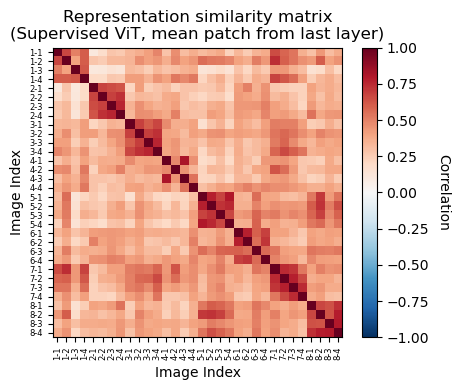

In [10]:
# RSM for mean patch from last layer (matplotlib only)
import matplotlib.pyplot as plt
import numpy as np

corr = np.corrcoef(mean_patch_last)

plt.figure(figsize=(5,4))
plt.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
cbar = plt.colorbar()
cbar.set_label("Correlation", rotation=270, labelpad=15)
plt.title("Representation similarity matrix\n(Supervised ViT, mean patch from last layer)")
plt.xlabel("Image Index")
plt.ylabel("Image Index")

# optional: label as 8x4 classes (same style as your notebook)
# This assumes images are ordered as 8 classes × 4 instances = 32.
# If not, comment this out.
try:
    labels = [f"{i+1}-{j+1}" for i in range(8) for j in range(4)]
    if len(labels) == corr.shape[0]:
        plt.xticks(ticks=np.arange(len(labels)), labels=labels, rotation=90, fontsize=6)
        plt.yticks(ticks=np.arange(len(labels)), labels=labels, fontsize=6)
except Exception as e:
    print("skip custom labels:", e)

plt.tight_layout()
plt.show()

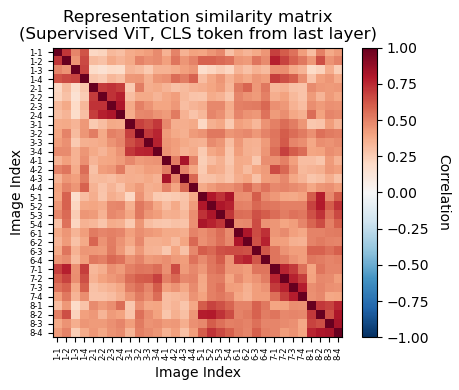

In [11]:
# RSM for CLS token from last layer
correlation_cls = np.corrcoef(cls_last)

plt.figure(figsize=(5,4))
plt.imshow(correlation_cls, cmap='RdBu_r', vmin=-1, vmax=1)
cbar = plt.colorbar()
cbar.set_label("Correlation", rotation=270, labelpad=15)
plt.title("Representation similarity matrix\n(Supervised ViT, CLS token from last layer)")
plt.xlabel("Image Index")
plt.ylabel("Image Index")

try:
    labels = [f"{i+1}-{j+1}" for i in range(8) for j in range(4)]
    if len(labels) == correlation_cls.shape[0]:
        plt.xticks(ticks=np.arange(len(labels)), labels=labels, rotation=90, fontsize=6)
        plt.yticks(ticks=np.arange(len(labels)), labels=labels, fontsize=6)
except Exception as e:
    print("skip custom labels:", e)

plt.tight_layout()
plt.show()

In [12]:
print("pooled_patch_tokens shape:", pooled_patch_tokens.shape)
print("cls_tokens shape:", cls_tokens.shape)

nlayers, nimg, dim = pooled_patch_tokens.shape
print(f"Number of layers: {nlayers}, Number of images: {nimg}, Dimension: {dim}")

# for each layer, compute the correlation matrix of the pooled patch tokens across images
patch_rsm = np.zeros((nlayers, nimg, nimg))
cls_rsm = np.zeros((nlayers, nimg, nimg))
for li in range(nlayers):
    patch_rsm[li] = np.corrcoef(pooled_patch_tokens[li])
    cls_rsm[li] = np.corrcoef(cls_tokens[li])

pooled_patch_tokens shape: (13, 32, 768)
cls_tokens shape: (13, 32, 768)
Number of layers: 13, Number of images: 32, Dimension: 768


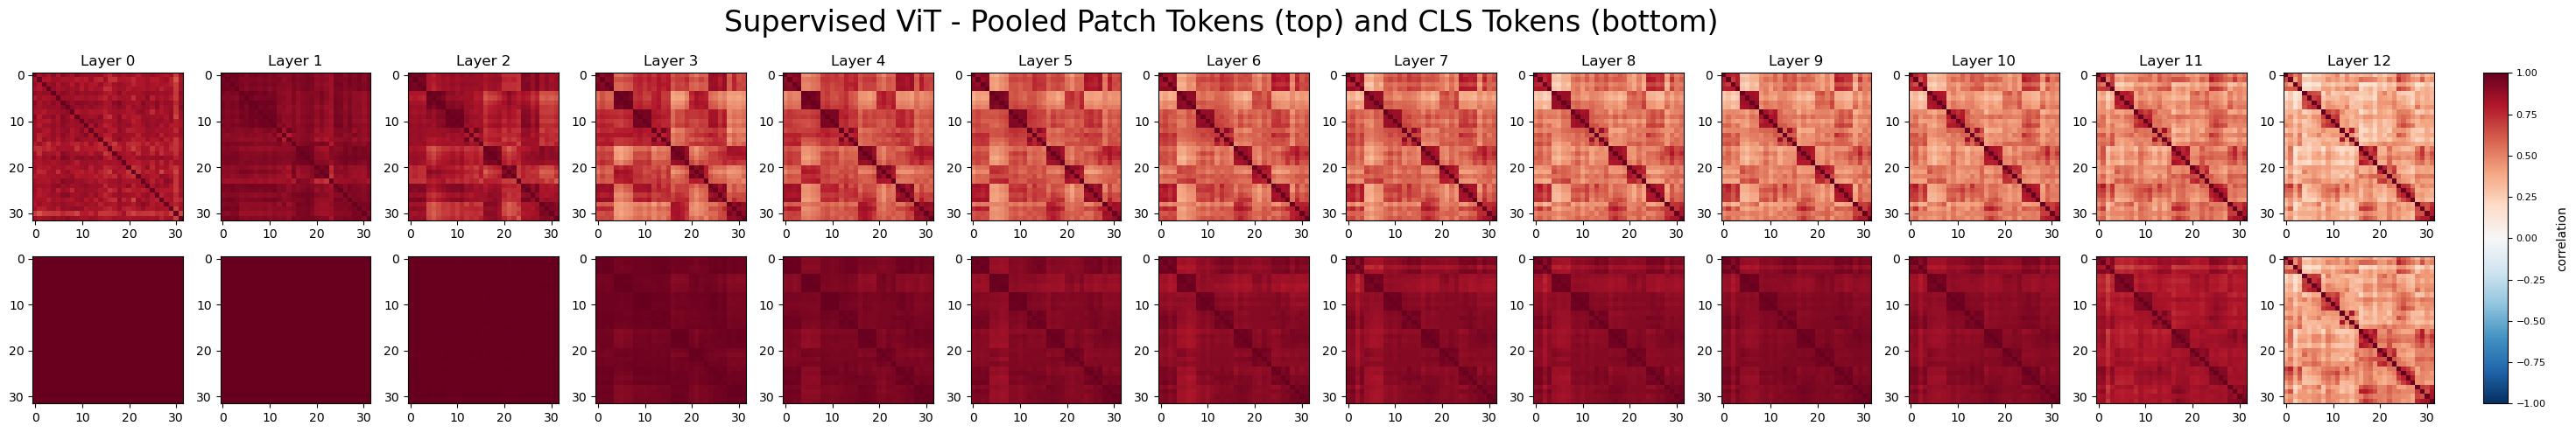

In [14]:
# visualize the rsm for each layer
nlayers = 13
fig, axes = plt.subplots(2, nlayers, figsize=(2*nlayers+2, 5))

for li in range(nlayers):
    img = axes[0, li].imshow(patch_rsm[li],
                             cmap='RdBu_r',
                             vmin=-1, vmax=1,
                             aspect='auto')
    axes[0, li].set_title(f"Layer {li}")
    
    axes[1, li].imshow(cls_rsm[li],
                       cmap='RdBu_r',
                       vmin=-1, vmax=1,
                       aspect='auto')

plt.suptitle(
    "Supervised ViT - Pooled Patch Tokens (top) and CLS Tokens (bottom)",
    fontsize=24
)

plt.tight_layout()

# ---- Add shared colorbar outside ----
pos = axes[0, -1].get_position()

cax = fig.add_axes([
    pos.x1 + 0.02,     # slight right shift
    axes[1, 0].get_position().y0,  # bottom of bottom row
    0.01,             # width
    axes[0, 0].get_position().y1 - axes[1, 0].get_position().y0  # full height
])

cbar = fig.colorbar(img, cax=cax)
cbar.set_label('correlation', labelpad=8)
cbar.ax.tick_params(labelsize=8)

# save
plt.savefig("../figures/supervised_corr_matrix.png",
            dpi=300,
            bbox_inches='tight')

plt.show()